# **Quick Trading Strategy**

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import os
import sys

import datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

import warnings
warnings.filterwarnings('ignore')

from typing import Tuple, Dict, Any, List
from pathlib import Path

from datetime import datetime, timedelta, time
import time

from tqdm.notebook import tqdm

src_path = os.path.abspath('../src')
sys.path.append(src_path)

data_path = os.path.abspath('../data')
sys.path.append(data_path)

from crypto_futures_perp_eda import summarize_symbol

# This line tells Pandas to use standard decimal formatting for large/small numbers.
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_columns', None)

In [4]:
eth_quote_df = pd.read_csv('../data/BTCUSDT_quote.csv')
btc_trade_df = pd.read_csv('../data/BTCUSDT_trade.csv')

In [10]:
print(btc_trade_df['amount'].min())

0.001


In [8]:
eth_trade_df = pd.read_csv('../data/ETHUSDT_trade.csv')
print(eth_trade_df['amount'].min())
sol_trade_df = pd.read_csv('../data/SOLUSDT_trade.csv')
print(sol_trade_df['amount'].min())
xrp_trade_df = pd.read_csv('../data/XRPUSDT_trade.csv')
print(xrp_trade_df['amount'].min())

0.001
0.01
0.1


In [10]:
btc_quote_df.columns[:20]

Index(['exchange', 'symbol', 'timestamp', 'local_timestamp', 'asks[0].price',
       'asks[0].amount', 'bids[0].price', 'bids[0].amount', 'asks[1].price',
       'asks[1].amount', 'bids[1].price', 'bids[1].amount', 'asks[2].price',
       'asks[2].amount', 'bids[2].price', 'bids[2].amount', 'asks[3].price',
       'asks[3].amount', 'bids[3].price', 'bids[3].amount'],
      dtype='object')

In [11]:
btc_quote_df.columns[-10:]

Index(['bids[22].price', 'bids[22].amount', 'asks[23].price',
       'asks[23].amount', 'bids[23].price', 'bids[23].amount',
       'asks[24].price', 'asks[24].amount', 'bids[24].price',
       'bids[24].amount'],
      dtype='object')

In [12]:
btc_trade_df.columns

Index(['exchange', 'symbol', 'timestamp', 'local_timestamp', 'id', 'side',
       'price', 'amount'],
      dtype='object')

## **Basic EDA**

In [19]:
# 0. Convert timestamps from ms → pandas datetime
btc_quote_df['dt'] = pd.to_datetime(btc_quote_df['timestamp'], unit='us')
btc_trade_df['dt'] = pd.to_datetime(btc_trade_df['timestamp'], unit='us')

# 0.1 Also store the date (no time) for grouping
btc_quote_df['date'] = btc_quote_df['dt'].dt.date
btc_trade_df['date'] = btc_trade_df['dt'].dt.date

In [33]:
# 0.1 Check that timestamps are increasing (no time reversals)
# Ensure dt is sorted
print(len(btc_quote_df), len(btc_trade_df))

btc_quote_df = btc_quote_df.sort_values('dt').reset_index(drop=True)
btc_trade_df = btc_trade_df.sort_values('dt').reset_index(drop=True)

# Check monotonicity
quote_time_ok = (btc_quote_df['dt'].diff().dropna() >= pd.Timedelta(0)).all()
trade_time_ok = (btc_trade_df['dt'].diff().dropna() >= pd.Timedelta(0)).all()

print("Quote timestamps monotonic:", quote_time_ok)
print("Trade timestamps monotonic:", trade_time_ok)

print(len(btc_quote_df), len(btc_trade_df))

1589222 4671690
Quote timestamps monotonic: True
Trade timestamps monotonic: True
1589222 4671690


In [36]:
# 0.2 Check for invalid prices or volumes
invalid_quote_prices = btc_quote_df[
    (btc_quote_df.filter(like='price') <= 0).any(axis=1)
]
print("Invalid quote price rows:", len(invalid_quote_prices))

invalid_quote_amounts = btc_quote_df[
    (btc_quote_df.filter(like='amount') < 0).any(axis=1)
]
print("Invalid quote amount rows:", len(invalid_quote_amounts))

invalid_trade = btc_trade_df[
    (btc_trade_df['price'] <= 0) | (btc_trade_df['amount'] <= 0)
]
print("Invalid trade rows:", len(invalid_trade))

Invalid quote price rows: 0
Invalid quote amount rows: 0
Invalid trade rows: 0


In [37]:
# 0.3 Validate Order Book Consistency
invalid_cross = btc_quote_df[
    btc_quote_df['bids[0].price'] >= btc_quote_df['asks[0].price']
]

print("Crossed market rows:", len(invalid_cross))

Crossed market rows: 0


In [38]:
# 0.4 Check depth ladder ordering
ask_price_cols = [col for col in btc_quote_df.columns if 'asks[' in col and '.price' in col]

ask_errors = 0
for row in btc_quote_df[ask_price_cols].itertuples(index=False):
    if not all(row[i] <= row[i+1] for i in range(len(row)-1)):
        ask_errors += 1

print("Rows with invalid ASK ladder:", ask_errors)

Rows with invalid ASK ladder: 0


In [39]:
bid_price_cols = [col for col in btc_quote_df.columns if 'bids[' in col and '.price' in col]

bid_errors = 0
for row in btc_quote_df[bid_price_cols].itertuples(index=False):
    if not all(row[i] >= row[i+1] for i in range(len(row)-1)):
        bid_errors += 1

print("Rows with invalid BID ladder:", bid_errors)

Rows with invalid BID ladder: 0


In [40]:
btc_quote_df.isna().sum().sum(), btc_trade_df.isna().sum().sum()

(0, 0)

Everything seems good so far

### 1. Check data coverage (how many days, min/max)

In [22]:
print("QUOTE dt range:", btc_quote_df['dt'].min(), "→", btc_quote_df['dt'].max())
print("TRADE dt range:", btc_trade_df['dt'].min(), "→", btc_trade_df['dt'].max())

print("QUOTE unique days:", btc_quote_df['date'].unique())
print("TRADE unique days:", btc_trade_df['date'].unique())

QUOTE dt range: 2025-08-01 00:00:00.245000 → 2025-08-01 23:59:59.956000
TRADE dt range: 2025-08-01 00:00:01.745000 → 2025-08-01 23:59:59.980000
QUOTE unique days: [datetime.date(2025, 8, 1)]
TRADE unique days: [datetime.date(2025, 8, 1)]


### 2. Basic daily stats – volume, trade count, quote count

#### 2.1 Daily trading volume and number of trades (from trade data)

In [25]:
# signed volume not needed yet, just total
daily_trade_stats = (
    btc_trade_df
    .groupby('date')
    .agg(
        total_volume=('amount', 'sum'),
        num_trades = ('amount', 'count')
    )
)

print(daily_trade_stats)

            total_volume  num_trades
date                                
2025-08-01    221282.099     4671690


#### 2.2 Daily number of quote updates

In [27]:
daily_quote_stats = (
    btc_quote_df
    .groupby('date')
    .agg(num_quotes=('exchange', 'count'))
)

print(daily_quote_stats)

            num_quotes
date                  
2025-08-01     1589222


In [31]:
# ----------------------------------------------------
# 💰 New: Set display options to suppress scientific notation
# This line tells Pandas to use standard decimal formatting for large/small numbers.
pd.options.display.float_format = '{:.6f}'.format
# ----------------------------------------------------

# 1. # 3. Compute midprice, spread, spread in bps
best_ask = btc_quote_df['asks[0].price']
best_bid = btc_quote_df['bids[0].price']

btc_quote_df['mid'] = (best_ask + best_bid) / 2
btc_quote_df['spread'] = best_ask - best_bid
# Formula for spread in basis points (bps)
btc_quote_df['spread_bps'] = btc_quote_df['spread'] / btc_quote_df['mid'] * 1e4 # 1e4 -> basis points

print(btc_quote_df[['spread', 'spread_bps']].describe())

              spread     spread_bps
count 1589222.000000 1589222.000000
mean        0.122955       0.010717
std         0.427061       0.037307
min         0.100000       0.008621
25%         0.100000       0.008662
50%         0.100000       0.008695
75%         0.100000       0.008759
max       136.100000      11.894872


In [41]:
# 4. Daily median spread & average spread in bps
daily_spread_stats = (
    btc_quote_df
    .groupby('date')
    .agg(
        spread_median = ('spread', 'median'),
        spread_mean = ('spread', 'mean'),
        spread_bps_median = ('spread_bps', 'median'),
        spread_bps_mean = ('spread_bps', 'mean')
    )
)

print(daily_spread_stats)

            spread_median  spread_mean  spread_bps_median  spread_bps_mean
date                                                                      
2025-08-01       0.100000     0.122955           0.008695         0.010717


In [42]:
# 5. Volatility estimate (daily)
# sort just in case
btc_quote_df = btc_quote_df.sort_values('dt')

# midprice log returns (using consecutive quote updates)
btc_quote_df['log_mid'] = np.log(btc_quote_df['mid'])
btc_quote_df['ret'] = btc_quote_df['log_mid'].diff()

# remove NaN on first diff
returns = btc_quote_df.dropna(subset=['ret'])

daily_vol = (
    returns
    .groupby('date')
    .agg(
        vol_std = ('ret', 'std')  # this is std of log returns per quote-step
    )
)

print(daily_vol)

            vol_std
date               
2025-08-01 0.000011


<AxesSubplot:>

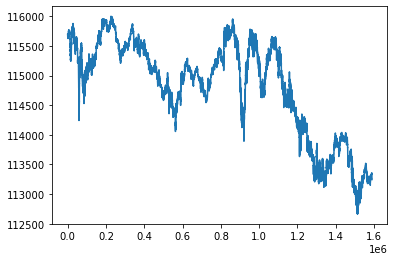

In [44]:
# Plot mid price to see if there is any jump
(0.5*(btc_quote_df['asks[0].price'] + btc_quote_df['bids[0].price'])).plot()

In [45]:
# 6. Top-of-book depth and imbalance
q_bid = btc_quote_df['bids[0].amount']
q_ask = btc_quote_df['asks[0].amount']

btc_quote_df['imbalance'] = (q_bid - q_ask) / (q_bid + q_ask)

depth_stats = (
    btc_quote_df
    .groupby('date')
    .agg(
        bid_depth_mean  = ('bids[0].amount', 'mean'),
        ask_depth_mean  = ('asks[0].amount', 'mean'),
        imbalance_mean  = ('imbalance', 'mean')
    )
)

print(depth_stats)

            bid_depth_mean  ask_depth_mean  imbalance_mean
date                                                      
2025-08-01       10.699957        9.901762       -0.005155


In [46]:
# 7. Trade-flow stats (basic, daily)
# signed volume: + for buy, - for sell
btc_trade_df['signed_volume'] = np.where(
    btc_trade_df['side'] == 'buy',
    btc_trade_df['amount'],
    -btc_trade_df['amount']
)

flow_stats = (
    btc_trade_df
    .groupby('date')
    .agg(
        net_signed_volume=('signed_volume', 'sum'),
        abs_signed_volume=('signed_volume', lambda x: x.abs().sum())
    )
)

print(flow_stats)

            net_signed_volume  abs_signed_volume
date                                            
2025-08-01       -8448.447000      221282.099000


### **Run for all assets**

In [4]:
btc_quote_df = pd.read_csv('../data/BTCUSDT_quote.csv')
btc_trade_df = pd.read_csv('../data/BTCUSDT_trade.csv')

eth_quote_df = pd.read_csv('../data/ETHUSDT_quote.csv')
eth_trade_df = pd.read_csv('../data/ETHUSDT_trade.csv')

hype_quote_df = pd.read_csv('../data/HYPEUSDT_quote.csv')
hype_trade_df = pd.read_csv('../data/HYPEUSDT_trade.csv')

sol_quote_df = pd.read_csv('../data/SOLUSDT_quote.csv')
sol_trade_df = pd.read_csv('../data/SOLUSDT_trade.csv')

xrp_quote_df = pd.read_csv('../data/XRPUSDT_quote.csv')
xrp_trade_df = pd.read_csv('../data/XRPUSDT_trade.csv')

In [11]:
# # 0. Convert timestamps from ms → pandas datetime
# hype_quote_df['dt'] = pd.to_datetime(hype_quote_df['timestamp'], unit='us')
# hype_trade_df['dt'] = pd.to_datetime(hype_trade_df['timestamp'], unit='us')

# # 0.1 Also store the date (no time) for grouping
# hype_quote_df['date'] = hype_quote_df['dt'].dt.date
# hype_trade_df['date'] = hype_trade_df['dt'].dt.date

In [13]:
#hype_quote_df.head()

In [14]:
#hype_trade_df.head()

In [ ]:
summary_df = pd.DataFrame({
    'BTCUSDT': summarize_symbol(btc_quote_df, btc_trade_df),
    'ETHUSDT': summarize_symbol(eth_quote_df, eth_trade_df),
    'HYPEUSDT': summarize_symbol(hype_quote_df, hype_trade_df),
    'SOLUSDT': summarize_symbol(sol_quote_df, sol_trade_df),
    'XRPUSDT': summarize_symbol(xrp_quote_df, xrp_trade_df),
})
summary_df

-0.005155064646874666


In [57]:
hype_trade_df['notional'] = hype_trade_df['price'] * hype_trade_df['amount']
hype_trade_df['notional'].describe()

count   1686533.000000
mean        320.688099
std        1642.488257
min           0.363720
25%          12.175200
50%          50.302690
75%         249.144550
max      365998.024000
Name: notional, dtype: float64

In [69]:
def get_spread_stats(quote_df, symbol):
    spread = quote_df['asks[0].price'] - quote_df['bids[0].price']
    mid = (quote_df['asks[0].price'] + quote_df['bids[0].price']) / 2
    spread_bps = spread / mid * 1e4
    m = spread_bps.median()

    widen_stats = {
        "pct_spread>2bps":   (spread_bps > 2).mean(),
        "pct_spread>5bps":   (spread_bps > 5).mean(),
        "pct_spread>10bps":  (spread_bps > 10).mean(),
    }
    print(symbol)
    print(widen_stats)
    
    is_wide = spread_bps > 5  # example threshold
    wide_blocks = is_wide.ne(is_wide.shift()).cumsum()
    durations = is_wide.groupby(wide_blocks).sum()  # length of each wide block
    print(durations.describe())

In [70]:
get_spread_stats(btc_quote_df, 'BTC')

BTC
{'pct_spread>2bps': 2.7057264497974482e-05, 'pct_spread>5bps': 7.550864511062645e-06, 'pct_spread>10bps': 6.292387092552205e-07}
count   21.000000
mean     0.571429
std      0.676123
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      2.000000
dtype: float64


In [71]:
get_spread_stats(eth_quote_df, 'ETH')

ETH
{'pct_spread>2bps': 0.0003305252860957612, 'pct_spread>5bps': 3.9492911022471465e-05, 'pct_spread>10bps': 6.683415711495171e-06}
count   107.000000
mean      0.607477
std       0.710527
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       3.000000
dtype: float64


In [72]:
get_spread_stats(sol_quote_df, 'SOL')

SOL
{'pct_spread>2bps': 0.0004822761973223001, 'pct_spread>5bps': 5.79219200323875e-05, 'pct_spread>10bps': 1.4023201692051711e-05}
count   113.000000
mean      0.840708
std       1.467301
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max      10.000000
dtype: float64


In [73]:
get_spread_stats(xrp_quote_df, 'XRP')

XRP
{'pct_spread>2bps': 0.0009861369867774483, 'pct_spread>5bps': 4.902757832310788e-05, 'pct_spread>10bps': 1.2412045145090602e-06}
count   99.000000
mean     0.797980
std      1.097119
min      0.000000
25%      0.000000
50%      0.000000
75%      1.000000
max      5.000000
dtype: float64


In [58]:
hype_spread = hype_quote_df['asks[0].price'] - hype_quote_df['bids[0].price']
hype_mid = (hype_quote_df['asks[0].price'] + hype_quote_df['bids[0].price']) / 2
hype_spread_bps = hype_spread / hype_mid * 1e4
m = hype_spread_bps.median()

widen_stats = {
    "pct_spread>2bps":   (hype_spread_bps > 2).mean(),
    "pct_spread>5bps":   (hype_spread_bps > 5).mean(),
    "pct_spread>10bps":  (hype_spread_bps > 10).mean(),
}
widen_stats

{'pct_spread>2bps': 0.002993583250927951,
 'pct_spread>5bps': 0.00013794623545473151,
 'pct_spread>10bps': 5.247954609690873e-06}

In [59]:
m

0.25328318326245697

In [60]:
is_wide = hype_spread_bps > 5  # example threshold
wide_blocks = is_wide.ne(is_wide.shift()).cumsum()
durations = is_wide.groupby(wide_blocks).sum()  # length of each wide block
durations.describe()

count   281.000000
mean      0.654804
std       0.881387
min       0.000000
25%       0.000000
50%       0.000000
75%       1.000000
max       5.000000
dtype: float64

In [79]:
1+1

2